In [1]:
!pip install -q datasets
!pip install -q evaluate
!pip install -q accelerate -U
!pip install --upgrade transformers>=4.8.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 7.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
t

In [2]:
import requests
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


local = False

2025-08-02 08:45:04.337894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754124304.513268      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754124304.563606      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


cuda


In [3]:
model_name = "google/vit-base-patch16-224"                        # the model name
model_name="google/vit-large-patch16-224-in21k"
model_name="google/vit-base-patch16-224-in21k"
image_processor = ViTImageProcessor.from_pretrained(model_name)   # load the image processor
model = ViTForImageClassification.from_pretrained(model_name)     # loading the pre-trained model

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
train_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
val_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
test_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'
auto_test = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/auto_test'
cat_dir = '/kaggle/input/cat-knee/clean'

In [5]:
import os

# ¿La carpeta raíz está ahí?
print(os.path.exists('/kaggle/input/knee-osteoarthritis-dataset-with-severity'))

True


In [6]:
print(os.listdir('/kaggle/input/knee-osteoarthritis-dataset-with-severity'))

['auto_test', 'val', 'test', 'train']


**Load Dataset**

In [7]:
from datasets import load_dataset

ds = load_dataset(
    "imagefolder",
    data_files={
        "train":      "/kaggle/input/knee-osteoarthritis-dataset-with-severity/train/*/*.png",
        "validation": "/kaggle/input/knee-osteoarthritis-dataset-with-severity/val/*/*.png",
        "test":       "/kaggle/input/knee-osteoarthritis-dataset-with-severity/test/*/*.png",
    },
)
print(ds)


Resolving data files:   0%|          | 0/5778 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/826 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1656 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5778
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 826
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1656
    })
})


In [8]:
labels = ds["train"].features["label"]
labels

ClassLabel(names=['0', '1', '2', '3', '4'], id=None)

**Data Preprocessing**

In [9]:
def transform(examples):
  # convert all images to RGB format, then preprocessing it using our image processor
  inputs = image_processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")

  # we also shouldn't forget about the labels
  inputs["labels"] = examples["label"]

  return inputs

# use the with_transform() method to apply the transform to the dataset on the fly during training
dataset = ds.with_transform(transform)

In [10]:
import matplotlib.pyplot as plt
def show_image(dataset, split, index):
    data = dataset[split][index]
    if "image" in data:  # Original dataset
        image = data["image"]
        label = data["label"]

        plt.figure(figsize=(1, 1))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Class {label}", fontsize=8)
        plt.show()
    else:  # Transformed dataset
        image_tensor = data['pixel_values']
        label = data['labels']

        # Convert the tensor to a NumPy array and display the image
        image_array = image_tensor.numpy()  # Convert the torch tensor to a NumPy array
        plt.figure(figsize=(1, 1))
        plt.imshow(image_array.transpose(1, 2, 0))  # Matplotlib expects the channel dimension last
        plt.title(f"Class {label}", fontsize=8)
        plt.axis('off')  # Hide the axis
        plt.show()

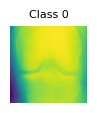

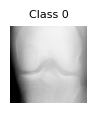

In [11]:
idx = 2
show_image(ds, "train", idx)
show_image(dataset, "train", idx)

In [12]:
for item in dataset["train"]:
  print(item["pixel_values"].shape)
  print(item["labels"])
  break

torch.Size([3, 224, 224])
0


In [13]:
labels = ds["train"].features["label"].names

def collate_fn(batch):
  return {
      "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
      "labels": torch.tensor([x["labels"] for x in batch]),
  }

In [14]:
from datasets import load_dataset, DatasetDict

cats_ds_full = load_dataset(
    cat_dir
)

cats_ds_full['validation'] = cats_ds_full['train']

cats_dataset_full = cats_ds_full.with_transform(transform)

Resolving data files:   0%|          | 0/83 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [15]:

split = cats_ds_full['train'].train_test_split(
    test_size=0.35,
    seed=42
)

cats_ds_split = DatasetDict({
    'train': split['train'],
    'validation': split['test']
})

cats_dataset_split = cats_ds_split.with_transform(transform)

print(cats_ds_split)



DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 53
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 30
    })
})


In [16]:
from transformers import TrainerCallback, TrainerControl, TrainerState

class EvalExtraDatasetCallback(TrainerCallback):
    def __init__(self, extra_dataset, prefix="extra"):
        super().__init__()
        self.extra_dataset = extra_dataset
        self.prefix = prefix
        self.trainer = None        # Se asigna más abajo
        self._in_extra_eval = False  # ← bandera para evitar recursión

    def on_train_begin(self, args, state: TrainerState, control: TrainerControl, **kwargs):
        # Capturamos la instancia de Trainer automáticamente
        if "model" in kwargs and hasattr(kwargs["model"], "eval"):
            # En versiones recientes Trainer pasa trainer en kwargs
            self.trainer = kwargs.get("trainer", self.trainer)
        # Si no la capturamos aquí, la asignas manualmente como antes

    def on_evaluate(self, args, state: TrainerState, control: TrainerControl, metrics=None, **kwargs):
        # Si ya estoy dentro de la evaluación extra, no volver a evaluar
        if self._in_extra_eval:
            return control

        # 1) Muestro las métricas “estándar” de esta iteración
        print(f"\n>>> Métricas estándar (@ step {state.global_step}): {metrics}")

        # 2) Preparo para evaluar el dataset extra
        print(f">>> Evaluando métricas del dataset [{self.prefix}]…")
        self._in_extra_eval = True

        # 3) Llamo a evaluate con un prefix para que ya venga renombrado
        extra_metrics = self.trainer.evaluate(
            eval_dataset=self.extra_dataset,
            metric_key_prefix=self.prefix
        )

        self._in_extra_eval = False

        # 4) Muestro y logueo esas métricas extra
        print(f"\n>>> Métricas [{self.prefix}]: {extra_metrics}")
        self.trainer.log(extra_metrics)

        return control


In [17]:
from evaluate import load
import numpy as np

# load the accuracy and f1 metrics from the evaluate module
accuracy = load("accuracy")
f1 = load("f1")

def compute_metrics(eval_pred):
  # compute the accuracy and f1 scores & return them
  accuracy_score = accuracy.compute(predictions=np.argmax(eval_pred.predictions, axis=1), references=eval_pred.label_ids)
  f1_score = f1.compute(predictions=np.argmax(eval_pred.predictions, axis=1), references=eval_pred.label_ids, average="macro")
  return {**accuracy_score, **f1_score}

In [18]:
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
def print_metrics_report(trainer, dataset, regression=False, split="validation"):
    print(f"\n=== Métricas para el split: {split} ===\n")

    # Obtener predicciones
    predictions_output = trainer.predict(dataset[split])
    
    y_true = predictions_output.label_ids
    y_pred = predictions_output.predictions

    if regression:
        # Para tareas de regresión
        y_pred = y_pred.flatten()

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        print(f"📈 MSE: {mse:.4f}")
        print(f"📈 MAE: {mae:.4f}")
        print(f"📈 R² : {r2:.4f}")

    else:
        # Para clasificación
        y_pred = np.argmax(y_pred, axis=1)

        report = classification_report(y_true, y_pred, zero_division=0, digits=4)
        print(report)

In [19]:
import matplotlib.pyplot as plt

def plot_regression_scatter(trainer, dataset_val):
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred = outputs.predictions.squeeze(-1)
    plt.scatter(y_true, y_pred)
    plt.plot([0,5],[0,5], linestyle='--')  # línea de identidad
    plt.xlabel("Valor real")
    plt.ylabel("Predicción")
    plt.show()



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def plot_regression_confusion(trainer, dataset_val, num_classes=6):
    # 1) Predicción del Trainer
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids            # deberían ser enteros 0–5 o floats sin decimales
    y_pred = outputs.predictions.squeeze(-1)  # valores continuos

    # 2) Convierte a clases redondeando y limitando al rango [0, num_classes-1]
    y_pred_cls = np.rint(y_pred).astype(int)
    y_pred_cls = np.clip(y_pred_cls, 0, num_classes-1)

    # 3) Matriz de confusión
    cm = confusion_matrix(y_true, y_pred_cls, labels=np.arange(num_classes))

    # 4) Dibujar
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[str(i) for i in range(num_classes)]
    )
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
    ax.set_title("Matriz de confusión (regresión → clases)")
    plt.show()


In [20]:
from scipy.special import softmax
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_multiclass(trainer, dataset_val):
    # 1) Predecir
    outputs = trainer.predict(dataset_val)
    logits = outputs.predictions
    y_true = outputs.label_ids

    # 2) Logits → probabilidades
    probs = softmax(logits, axis=1)

    # 3) Cálculo FPR, TPR, AUC
    num_classes = probs.shape[1]
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(num_classes):
        y_bin = (y_true == i).astype(int)
        fpr[i], tpr[i], _ = roc_curve(y_bin, probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 4) Ploteo
    plt.figure(figsize=(6, 4))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f"Clase {i} (AUC = {roc_auc[i]:.3f})")
    plt.plot([0,1], [0,1], "--", lw=1, color="gray")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC multiclas")
    plt.legend(loc="lower right")
    plt.show()


In [21]:
print({str(i): c for i, c in enumerate(labels)})

{'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}


In [22]:

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
def compute_metrics_regression(eval_pred):
    preds, labels = eval_pred
    # preds viene con forma (batch_size, 1)
    preds = preds.squeeze(-1)
    mse = mean_squared_error(labels, preds)
    mae = mean_absolute_error(labels, preds)
    return {
        "mse": mse,
        "rmse": np.sqrt(mse),
        "mae": mae,
    }

In [23]:
def map_labe_neg_pos(example):
    label = example["labels"]
    if label in [0, 1]:
        return {"label": 0}
        
    return {"label": 1}


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

def plot_regression_confusion_and_metrics(trainer, dataset_val):
    # 1) Predecir
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred_cont = outputs.predictions.squeeze(-1)

    # 2) Rango dinámico según datos reales
    min_real = int(np.min(y_true))
    max_real = int(np.max(y_true))
    clases = np.arange(min_real, max_real+1)

    # 3) Discretizar + clip
    y_pred = np.rint(y_pred_cont).astype(int)
    y_pred = np.clip(y_pred, min_real, max_real)

    # 4) Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(cm, display_labels=clases)
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
    ax.set_title(f"Matriz de confusión (regresión → clases {min_real}–{max_real})")
    plt.show()

    # 5) Métricas por clase
    precision, recall, f1_score, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=clases,
        average=None,
        zero_division=0
    )

    df_metrics = pd.DataFrame({
        "precision": precision,
        "recall":    recall,
        "f1-score":  f1_score,
        "support":   support
    }, index=[f"clase_{c}" for c in clases])

    display(df_metrics)

    # 6) Cálculo de macro‑promedios
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=clases,
        average="macro",
        zero_division=0
    )

    print(f"\n📊 Métricas macro‑promedio:")
    print(f"  • Precision media: {precision_macro:.3f}")
    print(f"  • Recall medio:    {recall_macro:.3f}")
    print(f"  • F1‑score medio:  {f1_macro:.3f}\n")

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=clases,
        average="micro",
        zero_division=0
    )

    print(f"\n📊 Métricas micro‑promedio:")
    print(f"  • Precision media: {precision_macro:.3f}")
    print(f"  • Recall medio:    {recall_macro:.3f}")
    print(f"  • F1‑score medio:  {f1_macro:.3f}\n")


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_regression_roc(trainer, dataset_val):
    # 1) Predecir
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred_cont = outputs.predictions.squeeze(-1)

    # 2) Rango dinámico según datos reales
    min_real = int(np.min(y_true))
    max_real = int(np.max(y_true))
    clases = np.arange(min_real, max_real+1)
    num_classes = len(clases)

    # 3) Discretizar + clip
    y_pred_cls = np.rint(y_pred_cont).astype(int)
    y_pred_cls = np.clip(y_pred_cls, min_real, max_real)

    # 4) Construir “probabilidades” one‑hot a partir de la clase predicha
    #    (1 para la clase elegida, 0 para el resto)
    probs = np.zeros((len(y_pred_cls), num_classes))
    for idx, c in enumerate(clases):
        probs[:, idx] = (y_pred_cls == c).astype(int)

    # 5) Calcular FPR, TPR y AUC para cada clase
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for idx, c in enumerate(clases):
        y_bin = (y_true == c).astype(int)
        fpr[idx], tpr[idx], _ = roc_curve(y_bin, probs[:, idx])
        roc_auc[idx] = auc(fpr[idx], tpr[idx])

    # 6) Dibujar todas las curvas en un mismo gráfico
    plt.figure(figsize=(6, 4))
    for idx, c in enumerate(clases):
        plt.plot(fpr[idx], tpr[idx], lw=2,
                 label=f"Clase {c} (AUC = {roc_auc[idx]:.3f})")

    # Línea de azar
    plt.plot([0, 1], [0, 1], "--", lw=1, color="gray")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC multiclas (regresión → clases discretas)")
    plt.legend(loc="lower right")
    plt.show()



In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_matrix_confussion(trainer, dataset_val):
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred = outputs.predictions.argmax(1)
    
    labels = dataset["train"].features['label'].names
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=45)

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_matriz_confusion(trainer, dataset_val, label_names):
    # 1) Predice sobre el dataset de validación
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred = outputs.predictions.argmax(axis=1)

    # 2) Calcula la matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # 3) La dibuja con etiquetas
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_names)
    disp.plot(xticks_rotation=45)
    plt.show()




# GATOS DIRECTO

In [28]:
from transformers import (
    AutoModelForImageClassification,
    AutoImageProcessor,
    Trainer,
    EarlyStoppingCallback
)
import gc
from peft import PeftModel
from datasets import Value
#model_name="google/vit-base-patch16-224"
model_name="google/efficientnet-b0"
tarea = 1
regression = True

eval_steps = 1 if local else 1
save_steps = eval_steps
num_epoch = 10 if local else 100

if tarea == 1:
    cats_dataset_split = cats_dataset_split.map(map_labe_neg_pos)
    cats_dataset_full = cats_dataset_full.map(map_labe_neg_pos)

Map:   0%|          | 0/53 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/83 [00:00<?, ? examples/s]

In [29]:
seen = []
for i in range(len(cats_dataset_split['validation'])):
    if cats_dataset_split['validation'][i]['labels'] not in seen:
        print(cats_dataset_split['validation'][i]['labels'])
        seen.append(cats_dataset_split['validation'][i]['labels'])

1
0


In [30]:
training_args = TrainingArguments(
  output_dir="./vit-base-food", # output directory
  # output_dir="./vit-base-skin-cancer",
  per_device_train_batch_size=32, # batch size per device during training
  eval_strategy="steps",    # evaluation strategy to adopt during training
  num_train_epochs=num_epoch,             # total number of training epochs
  # fp16=True,                    # use mixed precision
  save_steps=save_steps,                # number of update steps before saving checkpoint
  eval_steps=eval_steps,                # number of update steps before evaluating
  logging_steps=eval_steps,             # number of update steps before logging
  # save_steps=50,
  # eval_steps=50,
  # logging_steps=50,
  metric_for_best_model="eval_validation_loss",  # coincide con la métrica real
  greater_is_better=False,
  save_total_limit=2,             # limit the total amount of checkpoints on disk
  remove_unused_columns=False,    # remove unused columns from the dataset
  push_to_hub=False,              # do not push the model to the hub
  report_to='tensorboard',        # report metrics to tensorboard
  load_best_model_at_end=True,    # load the best model at the end of training
  learning_rate=1e-4
)


eval_sets = {
    "validation": cats_dataset_split['validation'],   # tu validación habitual
    #"cats": cats_dataset_full['validation'],          # tu split “extra”
}



image_processor = AutoImageProcessor.from_pretrained(
    model_name,
    size={"height": 224, "width": 224},
    use_fast=True
)

try:
    # Carga el modelo para clasificación de imágenes

    if regression:
        cats_dataset_split_reg = cats_dataset_split.cast_column("label", Value("float32"))
        
        model = AutoModelForImageClassification.from_pretrained(
            model_name,
            num_labels=1,
            problem_type="regression",
            ignore_mismatched_sizes=True,
        )

        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics_regression,    # tu función de métricas
            train_dataset=cats_dataset_split_reg["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    else:
        model = AutoModelForImageClassification.from_pretrained(
            model_name,
            num_labels=len(labels),
            id2label={str(i): c for i, c in enumerate(labels)},
            label2id={c: str(i) for i, c in enumerate(labels)},
            ignore_mismatched_sizes=True,
        )
    
        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics,    # tu función de métricas
            train_dataset=cats_dataset_split["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    #trainer.add_callback(cats_cb)  # registra el callback
    #cats_cb.trainer = trainer  

    # Entrenamos
    trainer.train()
except Exception as e:
    print(f"Error {e}")

preprocessor_config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Casting the dataset:   0%|          | 0/53 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Some weights of EfficientNetForImageClassification were not initialized from the model checkpoint at google/efficientnet-b0 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1280]) in the checkpoint and torch.Size([1, 1280]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_19/2675460190.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Step,Training Loss,Validation Loss,Validation Mse,Validation Rmse,Validation Mae
1,0.368600,0.296373,0.296373,0.544402,0.354194
2,0.401500,0.326799,0.326799,0.571663,0.393345
3,0.234900,0.342012,0.342012,0.584818,0.418028
4,0.205300,0.342837,0.342837,0.585523,0.393852
5,0.212700,0.303677,0.303677,0.551069,0.381303
6,0.070300,0.269569,0.269569,0.519200,0.353175
7,0.132400,0.276360,0.276360,0.525699,0.360668
8,0.044300,0.253980,0.253980,0.503965,0.355365
9,0.063600,0.215371,0.215371,0.464080,0.345626
10,0.142500,0.291499,0.291499,0.539907,0.381366


/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable o


=== Métricas para el split: validation ===



📈 MSE: 0.1653
📈 MAE: 0.3657
📈 R² : 0.2129


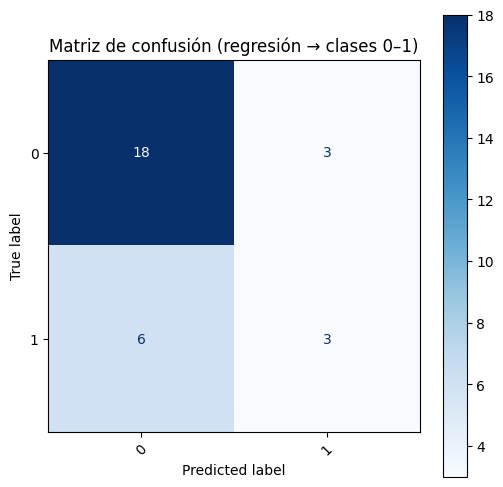

,precision,recall,f1-score,support
clase_0,0.75,0.857143,0.8,21
clase_1,0.50,0.333333,0.4,9



📊 Métricas macro‑promedio:
  • Precision media: 0.625
  • Recall medio:    0.595
  • F1‑score medio:  0.600


📊 Métricas micro‑promedio:
  • Precision media: 0.700
  • Recall medio:    0.700
  • F1‑score medio:  0.700



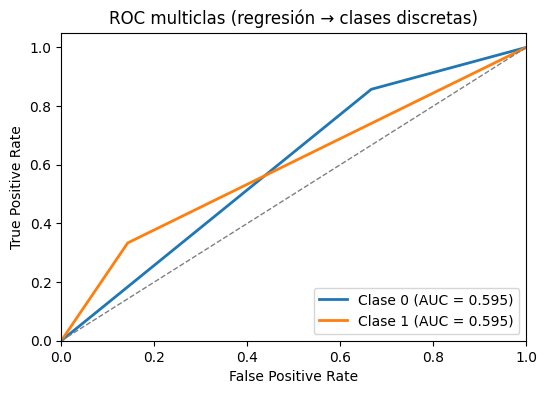

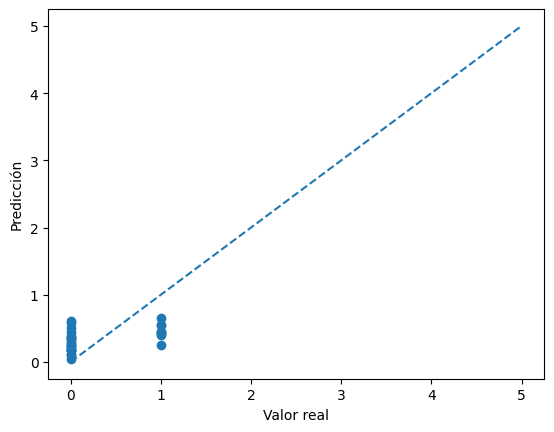

In [31]:
# Suponiendo que labels = ['bajo', 'medio', 'alto'] o como tú las llames:
print_metrics_report(trainer, cats_dataset_split, regression=regression, split="validation")
if not regression:
    label_names = ['0', '1', '2', '3', '4']
    if tarea == 1:
        label_names = ['0', '1']
    plot_matriz_confusion(trainer, cats_dataset_split["validation"], label_names)
    plot_matrix_confussion(trainer, cats_dataset_split['validation'])
    plot_roc_multiclass(trainer, cats_dataset_split["validation"])


# Y al final:
if regression:
    #plot_regression_confusion(trainer, cats_dataset_split["validation"])
    plot_regression_confusion_and_metrics(trainer, cats_dataset_split["validation"])
    plot_regression_roc(trainer, cats_dataset_split["validation"])
    plot_regression_scatter(trainer, cats_dataset_split["validation"])

# GATOS INDIRECTO

In [32]:
eval_steps = 50 if local else 100
save_steps = eval_steps
num_epoch = 2 if local else 20

if tarea == 1:
    dataset = dataset.map(map_labe_neg_pos)

Map:   0%|          | 0/5778 [00:00<?, ? examples/s]

Map:   0%|          | 0/826 [00:00<?, ? examples/s]

Map:   0%|          | 0/1656 [00:00<?, ? examples/s]

In [33]:
training_args = TrainingArguments(
  output_dir="./vit-base-food", # output directory
  # output_dir="./vit-base-skin-cancer",
  per_device_train_batch_size=32, # batch size per device during training
  eval_strategy="steps",    # evaluation strategy to adopt during training
  num_train_epochs=num_epoch,             # total number of training epochs
  # fp16=True,                    # use mixed precision
  save_steps=save_steps,                # number of update steps before saving checkpoint
  eval_steps=eval_steps,                # number of update steps before evaluating
  logging_steps=eval_steps,             # number of update steps before logging
  # save_steps=50,
  # eval_steps=50,
  # logging_steps=50,
  metric_for_best_model="eval_validation_loss",  # coincide con la métrica real
  greater_is_better=False,
  save_total_limit=2,             # limit the total amount of checkpoints on disk
  remove_unused_columns=False,    # remove unused columns from the dataset
  push_to_hub=False,              # do not push the model to the hub
  report_to='tensorboard',        # report metrics to tensorboard
  load_best_model_at_end=True,    # load the best model at the end of training
  learning_rate=1e-5
)


eval_sets = {
    "validation": dataset['validation'],   # tu validación habitual
    "cats": cats_dataset_full['validation'],          # tu split “extra”
}

In [34]:
seen = []
for i in range(len(dataset['validation'])):
    if dataset['validation'][i]['labels'] not in seen:
        print(dataset['validation'][i]['labels'])
        seen.append(dataset['validation'][i]['labels'])

0
1


In [35]:

image_processor = AutoImageProcessor.from_pretrained(
    model_name,
    size={"height": 224, "width": 224},
    use_fast=True
)

try:
    # Carga el modelo para clasificación de imágenes

    if regression:
        dataset_reg = dataset.cast_column("label", Value("float32"))
        
        model = AutoModelForImageClassification.from_pretrained(
            model_name,
            num_labels=1,
            problem_type="regression",
            ignore_mismatched_sizes=True,
        )

        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics_regression,    # tu función de métricas
            train_dataset=dataset_reg["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    else:
        model = AutoModelForImageClassification.from_pretrained(
            model_name,
            num_labels=len(labels),
            id2label={str(i): c for i, c in enumerate(labels)},
            label2id={c: str(i) for i, c in enumerate(labels)},
            ignore_mismatched_sizes=True,
        )
    
        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics,    # tu función de métricas
            train_dataset=dataset["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )

    # Entrenamos
    trainer.train()
except Exception as e:
    print(f"Error {e}")

Casting the dataset:   0%|          | 0/5778 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/826 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1656 [00:00<?, ? examples/s]

Some weights of EfficientNetForImageClassification were not initialized from the model checkpoint at google/efficientnet-b0 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1280]) in the checkpoint and torch.Size([1, 1280]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_19/3195562979.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Validation Mse,Validation Rmse,Validation Mae,Cats Loss,Cats Mse,Cats Rmse,Cats Mae
100,0.401600,No log,0.291581,0.539983,0.428393,0.248026,0.248026,0.498022,0.463475
200,0.272200,No log,0.242004,0.491939,0.420057,0.237551,0.237551,0.487392,0.451970
300,0.229000,No log,0.217120,0.465962,0.397863,0.269647,0.269647,0.519276,0.478865
400,0.198000,No log,0.194859,0.441428,0.386350,0.298359,0.298359,0.546223,0.499723
500,0.188500,No log,0.188353,0.433997,0.370914,0.328567,0.328567,0.573207,0.511439
600,0.178500,No log,0.189769,0.435625,0.375273,0.325971,0.325971,0.570939,0.511451
700,0.171400,No log,0.179929,0.424180,0.360417,0.289182,0.289182,0.537756,0.486881
800,0.167800,No log,0.172467,0.415292,0.346396,0.313513,0.313513,0.559922,0.499032
900,0.159700,No log,0.169419,0.411605,0.349817,0.322675,0.322675,0.568045,0.510157
1000,0.153800,No log,0.174159,0.417324,0.344805,0.278588,0.278588,0.527815,0.482577



=== Métricas para el split: validation ===



📈 MSE: 0.2877
📈 MAE: 0.4849
📈 R² : -0.2296


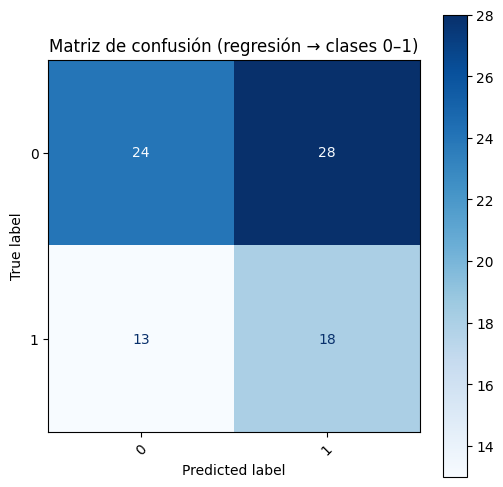

,precision,recall,f1-score,support
clase_0,0.648649,0.461538,0.539326,52
clase_1,0.391304,0.580645,0.467532,31



📊 Métricas macro‑promedio:
  • Precision media: 0.520
  • Recall medio:    0.521
  • F1‑score medio:  0.503


📊 Métricas micro‑promedio:
  • Precision media: 0.506
  • Recall medio:    0.506
  • F1‑score medio:  0.506



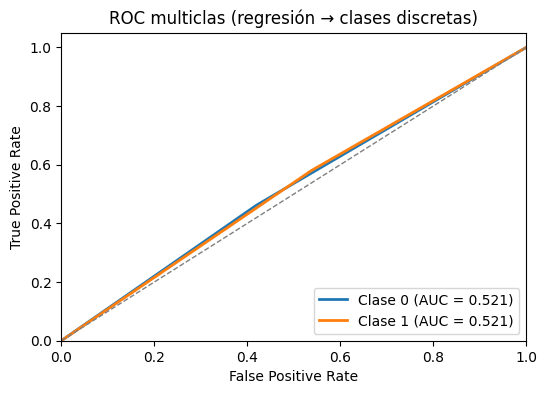

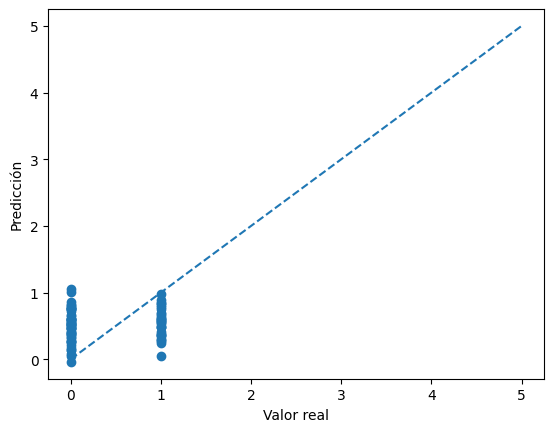

In [36]:
# Suponiendo que labels = ['bajo', 'medio', 'alto'] o como tú las llames:
print_metrics_report(trainer, cats_dataset_full, regression=regression, split="validation")
if not regression:
    label_names = ['0', '1', '2', '3', '4']
    if tarea == 1:
        label_names = ['0', '1']
    plot_matriz_confusion(trainer, cats_dataset_full["validation"], label_names)
    plot_matrix_confussion(trainer, cats_dataset_full['validation'])
    plot_roc_multiclass(trainer, cats_dataset_full["validation"])


# Y al final:
if regression:
    #plot_regression_confusion(trainer, cats_dataset_split["validation"])
    plot_regression_confusion_and_metrics(trainer, cats_dataset_full["validation"])
    plot_regression_roc(trainer, cats_dataset_full["validation"])
    plot_regression_scatter(trainer, cats_dataset_full["validation"])

# FINETUNING GATOS

In [37]:
eval_steps = 1 if local else 1
save_steps = eval_steps
num_epoch = 10 if local else 100


In [38]:
training_args = TrainingArguments(
  output_dir="./vit-base-food", # output directory
  # output_dir="./vit-base-skin-cancer",
  per_device_train_batch_size=32, # batch size per device during training
  eval_strategy="steps",    # evaluation strategy to adopt during training
  num_train_epochs=num_epoch,             # total number of training epochs
  # fp16=True,                    # use mixed precision
  save_steps=save_steps,                # number of update steps before saving checkpoint
  eval_steps=eval_steps,                # number of update steps before evaluating
  logging_steps=eval_steps,             # number of update steps before logging
  # save_steps=50,
  # eval_steps=50,
  # logging_steps=50,
  metric_for_best_model="eval_validation_loss",  # coincide con la métrica real
  greater_is_better=False,
  save_total_limit=2,             # limit the total amount of checkpoints on disk
  remove_unused_columns=False,    # remove unused columns from the dataset
  push_to_hub=False,              # do not push the model to the hub
  report_to='tensorboard',        # report metrics to tensorboard
  load_best_model_at_end=True,    # load the best model at the end of training
  learning_rate=1e-5
)


eval_sets = {
    "validation": cats_dataset_split['validation'],   # tu validación habitual
    #"cats": cats_dataset_full['validation'],          # tu split “extra”
}



image_processor = AutoImageProcessor.from_pretrained(
    model_name,
    size={"height": 224, "width": 224},
    use_fast=True
)

try:
    # Carga el modelo para clasificación de imágenes

    if regression:
        cats_dataset_split_reg = cats_dataset_split.cast_column("label", Value("float32"))
        
        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics_regression,    # tu función de métricas
            train_dataset=cats_dataset_split_reg["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    else:
        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics,    # tu función de métricas
            train_dataset=cats_dataset_split["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    #trainer.add_callback(cats_cb)  # registra el callback
    #cats_cb.trainer = trainer  

    # Entrenamos
    trainer.train()
except Exception as e:
    print(f"Error {e}")

/tmp/ipykernel_19/1369095067.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Validation Mse,Validation Rmse,Validation Mae
1,0.314700,0.232171,0.232171,0.481842,0.442990
2,0.338800,0.294360,0.294360,0.542550,0.494833
3,0.297800,0.306222,0.306222,0.553373,0.514863
4,0.193400,0.242739,0.242739,0.492685,0.450131
5,0.329600,0.262350,0.262350,0.512201,0.476613
6,0.234100,0.282506,0.282506,0.531513,0.494258
7,0.255200,0.262064,0.262064,0.511922,0.480601
8,0.253800,0.250056,0.250056,0.500056,0.471135
9,0.250700,0.266053,0.266053,0.515803,0.489181
10,0.302000,0.249375,0.249375,0.499374,0.462698


/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")
/usr/local/lib/python3.11/dist-packages/transformers/trainer.py:4140: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable o


=== Métricas para el split: validation ===



📈 MSE: 0.1886
📈 MAE: 0.3741
📈 R² : 0.1017


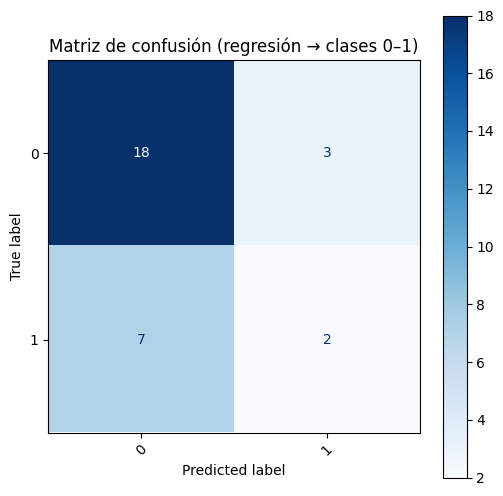

,precision,recall,f1-score,support
clase_0,0.72,0.857143,0.782609,21
clase_1,0.40,0.222222,0.285714,9



📊 Métricas macro‑promedio:
  • Precision media: 0.560
  • Recall medio:    0.540
  • F1‑score medio:  0.534


📊 Métricas micro‑promedio:
  • Precision media: 0.667
  • Recall medio:    0.667
  • F1‑score medio:  0.667



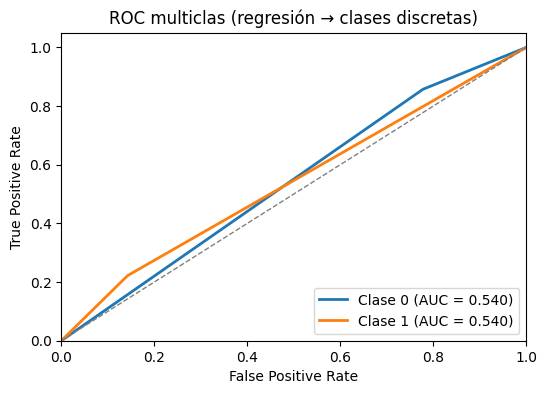

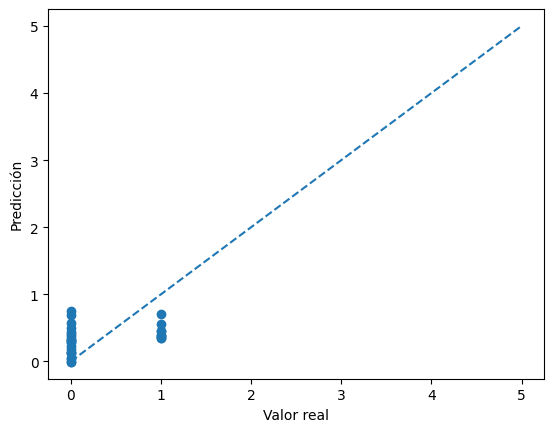

In [39]:
# Suponiendo que labels = ['bajo', 'medio', 'alto'] o como tú las llames:
print_metrics_report(trainer, cats_dataset_split, regression=regression, split="validation")
if not regression:
    label_names = ['0', '1', '2', '3', '4']
    if tarea == 1:
        label_names = ['0', '1']
    plot_matriz_confusion(trainer, cats_dataset_split["validation"], label_names)
    plot_matrix_confussion(trainer, cats_dataset_split['validation'])
    plot_roc_multiclass(trainer, cats_dataset_split["validation"])


# Y al final:
if regression:
    #plot_regression_confusion(trainer, cats_dataset_split["validation"])
    plot_regression_confusion_and_metrics(trainer, cats_dataset_split["validation"])
    plot_regression_roc(trainer, cats_dataset_split["validation"])
    plot_regression_scatter(trainer, cats_dataset_split["validation"])

from transformers import (
    AutoConfig,
    AutoModelForImageClassification,
    AutoImageProcessor,
    TrainingArguments,
    Trainer
)
from peft import PeftModel
import torch
import gc

# 1. NOMBRE DE MODELOS
base_model_name   = "google/vit-base-patch16-224-in21k"
lora_adapter_name = "neuralhaven/vit-large-patch16-224-in21k-finetuned-lora-medmnistv2"

# 2. LISTA REAL DE ETIQUETAS (¡sin ellipsis!)
# Si usas 🤗Datasets:
labels = dataset["train"].features["label"].names
# O manualmente:
# labels = ["normal", "adenoma", "carcinoma", "melanoma", "nevus"]

# 3. Procesador de imágenes
image_processor = AutoImageProcessor.from_pretrained(
    base_model_name,
    size={"height": 224, "width": 224},
    use_fast=True
)

# 4. Configuración con el número correcto de clases
config = AutoConfig.from_pretrained(
    base_model_name,
    num_labels=len(labels),
    id2label={str(i): lbl for i, lbl in enumerate(labels)},
    label2id={lbl: i      for i, lbl in enumerate(labels)}
)

# 5. Carga del modelo base (reemplaza la cabeza automáticamente)
base_model = AutoModelForImageClassification.from_pretrained(
    base_model_name,
    config=config,
    ignore_mismatched_sizes=True
)

# 6. Inyecta el adaptador LoRA sobre el modelo base
model = PeftModel.from_pretrained(
    base_model,
    lora_adapter_name
)


# 8. Argumentos de entrenamiento
local = False
eval_steps = 50 if local else 250

training_args = TrainingArguments(
    output_dir="./vit-large-medmnist",
    per_device_train_batch_size=32,
    num_train_epochs=8,
    eval_strategy="steps",
    save_steps=eval_steps,
    eval_steps=eval_steps,
    logging_steps=eval_steps,
    metric_for_best_model="eval_validation_loss",
    greater_is_better=False,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to="tensorboard",
    load_best_model_at_end=True,
    learning_rate=1e-4
)

# 9. Conjuntos de evaluación
eval_sets = {
    "validation": dataset["validation"],
    "cats":       cats_dataset["validation"]
}

# 10. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=dataset["train"],
    eval_dataset=eval_sets,
    tokenizer=image_processor,
    callbacks=[]
)

# 11. Entrenamiento
gc.collect()
trainer.train()


**Evaluation with Confusion Matrix**

**Generate Precision, Recall, F1 Score, Support**

**Generate Training & Loss Curves**

import matplotlib.pyplot as plt

data = trainer.state.log_history
# Extracting data for plotting
epochs = [entry['epoch'] for entry in data]  # Extract epoch values
train_losses = [entry['loss'] for entry in data if 'loss' in entry]  # Extract training losses
eval_losses = [entry['eval_loss'] for entry in data if 'eval_loss' in entry]  # Extract evaluation losses

# Plotting training and evaluation metrics
plt.figure(figsize=(6, 4))

plt.plot(epochs[:len(train_losses)], train_losses, label='Training Loss')
plt.plot(epochs[:len(eval_losses)], eval_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.title('Training and Evaluation Metrics Across Epochs')
plt.legend()
# plt.grid(True)
plt.show()

**Plot ROC Curves**